# تحلیل دیتاست WiFi Fingerprints برای مکان‌یابی داخل‌ساختمان (Indoor Positioning)

این نوت‌بوک تحلیل کاملی از داده‌های RSSI جمع‌آوری‌شده برای پایان‌نامه **مکان‌یابی مبتنی بر WiFi Fingerprinting و الگوریتم KNN** ارائه می‌دهد.

هدف: **شناسایی اینکه از میان چند نوع RSSI / Access Point موجود در محیط، کدام‌ها برای مکان‌یابی مناسب هستند.**

---

## فهرست تحلیل‌ها
1. بارگذاری و پاک‌سازی داده‌ها
2. آمار کلی دیتاست
3. تحلیل هر Access Point (تعداد مشاهده، میانگین، انحراف معیار، باند فرکانسی)
4. مناسب/نامناسب بودن APها (فیلتر بر اساس حداقل تعداد مشاهده)
5. تحلیل SSIDها
6. تعداد AP در هر طبقه
7. تعداد AP قابل مشاهده در هر Reference Point
8. توزیع و هیستوگرام RSSI
9. باکس‌پلات پایداری APهای برتر
10. پوشش APها (در چند درصد نقاط دیده شده‌اند)
11. همبستگی RSSI با فاصله
12. ماتریس ساختمان × طبقه
13. مجموعه پیشنهادی APها برای Fingerprinting


## ۱. بارگذاری و پاک‌سازی داده‌ها

ابتدا کتابخانه‌ها را وارد می‌کنیم و فایل `fingerprints.xlsx` را می‌خوانیم.
در مرحله پاک‌سازی:
- ردیف‌های فاقد `WifiBSSID` یا `WifiRSSI` حذف می‌شوند؛
- `BSSID`ها به حروف کوچک و بدون فضای خالی نرمال می‌شوند؛
- ستون جدید **Band** (باند فرکانسی) ساخته می‌شود.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)

DATA_PATH = Path("data/fingerprints.xlsx")

def freq_to_band(freq):
    return "2.4 GHz" if freq < 4000 else "5 GHz"

df = pd.read_excel(DATA_PATH, sheet_name="in")
print("ردیف خام:", len(df))

# پاک‌سازی
df["Building"] = df["Building"].astype(str).str.strip()
df = df.dropna(subset=["WifiBSSID", "WifiRSSI"]).copy()
df["WifiBSSID"] = df["WifiBSSID"].str.lower().str.strip()
df["WifiRSSI"] = pd.to_numeric(df["WifiRSSI"], errors="coerce")
df["WifiFrequency"] = pd.to_numeric(df["WifiFrequency"], errors="coerce")
df = df.dropna(subset=["WifiRSSI", "WifiFrequency"])
df["Band"] = df["WifiFrequency"].apply(freq_to_band)

print("ردیف پس از پاک‌سازی:", len(df))
df.head()

ردیف خام: 1756
ردیف پس از پاک‌سازی: 1756


,SampleID,ReferencePointID,Timestamp,Latitude,Longitude,Building,Floor,Room,CellID,TAC,...,NetworkType,WifiBSSID,WifiSSID,WifiRSSI,WifiFrequency,GPS_Latitude,GPS_Longitude,GPS_Accuracy,Source,Band
0,BC 127_F0_S002,BC 127_F0,2026-06-27T12:52:16.057613,36.312258,59.526555,BC,0,BC 127,132968981,30515,...,LTE,00:1f:fb:ea:2a:41,NaN,-92,2412,36.312374,59.526562,15.958,OSM_CLICK,2.4 GHz
1,BC 105_F0_S002,BC 105_F0,2026-06-27T12:33:40.878981,36.312485,59.526465,B,0,BC 105,132968981,30515,...,LTE,00:e0:4c:f9:63:c4,PSRES,-92,2437,36.312459,59.526538,14.641,OSM_CLICK,2.4 GHz
2,BC 105_F0_S003,BC 105_F0,2026-06-27T12:33:46.270831,36.312485,59.526465,B,0,BC 105,132968981,30515,...,LTE,00:e0:4c:f9:63:c4,PSRES,-92,2437,36.312459,59.526538,14.641,OSM_CLICK,2.4 GHz
3,AB 301_F2_S001,AB 301_F2,2026-06-27T12:57:07.105950,36.313030,59.526237,AB,2,AB 301,33853768,12618,...,LTE,02:29:09:9f:4d:9a,HP44FF7D,-80,2457,36.312801,59.526361,14.404,OSM_CLICK,2.4 GHz
4,AB 301_F2_S002,AB 301_F2,2026-06-27T12:57:21.365211,36.313028,59.526224,AB,2,AB 301,33853768,12618,...,LTE,02:29:09:9f:4d:9a,HP44FF7D,-80,2457,36.312802,59.526363,15.874,OSM_CLICK,2.4 GHz


## ۲. آمار کلی دیتاست

این جدول یک نمای کلی از ابعاد داده به ما می‌دهد: چند نقطه مرجع (Reference Point)، چند نمونه، چند ساختمان/طبقه و چند Access Point یکتا داریم.

In [2]:
summary = {
    "Total rows": len(df),
    "Unique Reference Points (RP)": df["ReferencePointID"].nunique(),
    "Unique Samples (SampleID)": df["SampleID"].nunique(),
    "Unique Buildings": df["Building"].nunique(),
    "Floors": ", ".join(map(str, sorted(df["Floor"].unique()))),
    "Unique BSSIDs (APs)": df["WifiBSSID"].nunique(),
    "Unique SSIDs": df["WifiSSID"].nunique(),
    "RSSI min (dBm)": int(df["WifiRSSI"].min()),
    "RSSI max (dBm)": int(df["WifiRSSI"].max()),
    "RSSI mean (dBm)": round(float(df["WifiRSSI"].mean()), 2),
    "RSSI std (dBm)": round(float(df["WifiRSSI"].std()), 2),
    "2.4 GHz rows": int((df["Band"] == "2.4 GHz").sum()),
    "5 GHz rows": int((df["Band"] == "5 GHz").sum()),
}
summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Total rows,1756
1,Unique Reference Points (RP),45
2,Unique Samples (SampleID),129
3,Unique Buildings,5
4,Floors,"0, 1, 2, 3"
5,Unique BSSIDs (APs),76
6,Unique SSIDs,25
7,RSSI min (dBm),-96
8,RSSI max (dBm),-31
9,RSSI mean (dBm),-72.21


## ۳. تحلیل هر Access Point (BSSID)

این مهم‌ترین جدول تحلیل است. برای هر AP موارد زیر محاسبه شده است:
- **Observations**: تعداد دفعات مشاهده
- **Mean / Std / Min / Max RSSI**: آمار توصیفی قدرت سیگنال (Std پایین‌تر = پایدارتر)
- **Band**: باند فرکانسی (2.4 GHz یا 5 GHz)
- **Coverage_pct**: در چند درصد نقاط مرجع دیده شده است
- **Suitable**: آیا حداقل ۱۰ بار مشاهده شده است (YES/NO)

In [3]:
MIN_OBSERVATIONS = 10
total_rp = df["ReferencePointID"].nunique()

agg = (df.groupby("WifiBSSID")
         .agg(SSID=("WifiSSID", lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None),
              Observations=("WifiRSSI", "count"),
              Mean_RSSI_dBm=("WifiRSSI", "mean"),
              Std_RSSI=("WifiRSSI", "std"),
              Min_RSSI_dBm=("WifiRSSI", "min"),
              Max_RSSI_dBm=("WifiRSSI", "max"),
              Frequency_MHz=("WifiFrequency", lambda s: int(s.mode().iloc[0])),
              Seen_in_RPs=("ReferencePointID", "nunique"))
         .reset_index())
agg["Band"] = agg["Frequency_MHz"].apply(freq_to_band)
agg["Std_RSSI"] = agg["Std_RSSI"].round(2)
agg["Mean_RSSI_dBm"] = agg["Mean_RSSI_dBm"].round(2)
agg["Coverage_pct"] = (agg["Seen_in_RPs"] / total_rp * 100).round(1)
agg["Suitable"] = np.where(agg["Observations"] >= MIN_OBSERVATIONS, "YES", "NO")
agg = agg.sort_values("Observations", ascending=False).reset_index(drop=True)
agg

,WifiBSSID,SSID,Observations,Mean_RSSI_dBm,Std_RSSI,Min_RSSI_dBm,Max_RSSI_dBm,Frequency_MHz,Seen_in_RPs,Band,Coverage_pct,Suitable
0,b2:8b:a9:9b:8d:2a,WiFi-FUM,84,-51.86,10.57,-74,-34,5180,30,5 GHz,66.7,YES
1,b2:8b:a9:9b:8c:8e,WiFi-FUM,84,-59.29,11.09,-87,-31,5805,30,5 GHz,66.7,YES
2,b2:8b:a9:9a:8c:8e,WiFi-FUM,82,-58.66,10.37,-78,-38,2437,30,2.4 GHz,66.7,YES
3,b2:8b:a9:9a:8d:2a,WiFi-FUM,81,-56.79,12.46,-86,-36,2412,30,2.4 GHz,66.7,YES
4,1c:6a:1b:7a:5d:d4,WiFi-FUM,78,-78.83,7.53,-94,-64,2412,30,2.4 GHz,66.7,YES
...,...,...,...,...,...,...,...,...,...,...,...,...
71,c4:ad:34:6f:d0:76,Baran3-W,1,-85.00,NaN,-85,-85,5640,1,5 GHz,2.2,NO
72,7a:60:8d:53:e1:cf,Redmi Note 14,1,-93.00,NaN,-93,-93,2462,1,2.4 GHz,2.2,NO
73,ac:8b:a9:8e:7d:ff,None,1,-95.00,NaN,-95,-95,5240,1,5 GHz,2.2,NO
74,b2:73:07:67:d8:72,iphone 7,1,-76.00,NaN,-76,-76,2437,1,2.4 GHz,2.2,NO


### ستون «مناسب؟» به‌صورت بصری

جدول زیر همان نتیجه‌ای است که استاد انتظار دارد:
از ۷۶ اکسس‌پوینت، چندتایشان برای مکان‌یابی ارزش دارند.

In [4]:
(agg[["WifiBSSID","SSID","Observations","Mean_RSSI_dBm","Std_RSSI","Band","Coverage_pct","Suitable"]]
   .style
   .applymap(lambda v: "background-color:#c8e6c9" if v=="YES" else ("background-color:#ffcdd2" if v=="NO" else ""), subset=["Suitable"])
   .bar(subset=["Observations"], color="#4C72B0"))

C:\Users\User\AppData\Local\Temp\ipykernel_20308\2899358679.py:3: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "background-color:#c8e6c9" if v=="YES" else ("background-color:#ffcdd2" if v=="NO" else ""), subset=["Suitable"])


,WifiBSSID,SSID,Observations,Mean_RSSI_dBm,Std_RSSI,Band,Coverage_pct,Suitable
0,b2:8b:a9:9b:8d:2a,WiFi-FUM,84,-51.860000,10.570000,5 GHz,66.700000,YES
1,b2:8b:a9:9b:8c:8e,WiFi-FUM,84,-59.290000,11.090000,5 GHz,66.700000,YES
2,b2:8b:a9:9a:8c:8e,WiFi-FUM,82,-58.660000,10.370000,2.4 GHz,66.700000,YES
3,b2:8b:a9:9a:8d:2a,WiFi-FUM,81,-56.790000,12.460000,2.4 GHz,66.700000,YES
4,1c:6a:1b:7a:5d:d4,WiFi-FUM,78,-78.830000,7.530000,2.4 GHz,66.700000,YES
5,1c:6a:1b:7b:5d:08,WiFi-FUM,68,-82.960000,2.980000,5 GHz,62.200000,YES
6,a8:a7:95:34:30:a1,HP-Print-A1-LaserJet Pro MFP,59,-76.630000,10.450000,2.4 GHz,55.600000,YES
7,1c:6a:1b:7b:5d:d4,WiFi-FUM,53,-82.530000,3.290000,5 GHz,55.600000,YES
8,fa:e2:c6:15:d2:90,WiFi-FUM,52,-85.540000,2.350000,5 GHz,53.300000,YES
9,02:29:09:9f:4d:9a,HP44FF7D,46,-83.830000,6.500000,2.4 GHz,42.200000,YES


## ۴. خلاصه مناسب/نامناسب بودن APها

In [5]:
summary_suit = agg.groupby("Suitable").agg(
    Count=("WifiBSSID","count"),
    Total_Observations=("Observations","sum"),
    Mean_RSSI=("Mean_RSSI_dBm","mean")
).reset_index()
summary_suit

,Suitable,Count,Total_Observations,Mean_RSSI
0,NO,28,62,-88.341429
1,YES,48,1694,-73.884792


## ۵. تحلیل SSIDها

SSID نام شبکه است. توجه کنید که شبکه **WiFi-FUM** با ۲۶ BSSID (اکسس‌پوینت فیزیکی مختلف) شبکه غالب دانشگاهی است و بیشترین ارزش مکان‌یابی را دارد.

In [6]:
ssid = (df.groupby("WifiSSID")
           .agg(Observations=("WifiRSSI","count"),
                Unique_BSSIDs=("WifiBSSID","nunique"),
                Mean_RSSI_dBm=("WifiRSSI","mean"),
                Seen_in_RPs=("ReferencePointID","nunique"))
           .reset_index().sort_values("Observations", ascending=False))
ssid["Mean_RSSI_dBm"] = ssid["Mean_RSSI_dBm"].round(2)
ssid

,WifiSSID,Observations,Unique_BSSIDs,Mean_RSSI_dBm,Seen_in_RPs
19,WiFi-FUM,1016,26,-71.22,44
8,HP-Print-A1-LaserJet Pro MFP,59,1,-76.63,25
10,HP44FF7D,46,1,-83.83,19
24,zeinab's mi,41,1,-59.44,14
22,kafobot,41,1,-74.59,15
5,Galaxy A34 5G 6E95,34,1,-71.82,12
6,HP-Print-11-LaserJet Pro MFP,27,1,-82.15,16
9,HP-Print-CD-LaserJet Pro MFP,23,1,-76.04,10
4,Galaxy A07 19a3,18,1,-87.67,9
18,TP-Link_E5CA,14,1,-90.21,9


## ۶. تعداد Access Point در هر طبقه

In [7]:
per_floor = (df.groupby("Floor")
               .agg(Unique_BSSIDs=("WifiBSSID","nunique"),
                    Unique_SSIDs=("WifiSSID","nunique"),
                    Observations=("WifiRSSI","count"),
                    Unique_RPs=("ReferencePointID","nunique"))
               .reset_index())
per_floor

,Floor,Unique_BSSIDs,Unique_SSIDs,Observations,Unique_RPs
0,0,35,10,594,14
1,1,2,2,2,1
2,2,27,7,102,3
3,3,45,16,1058,27


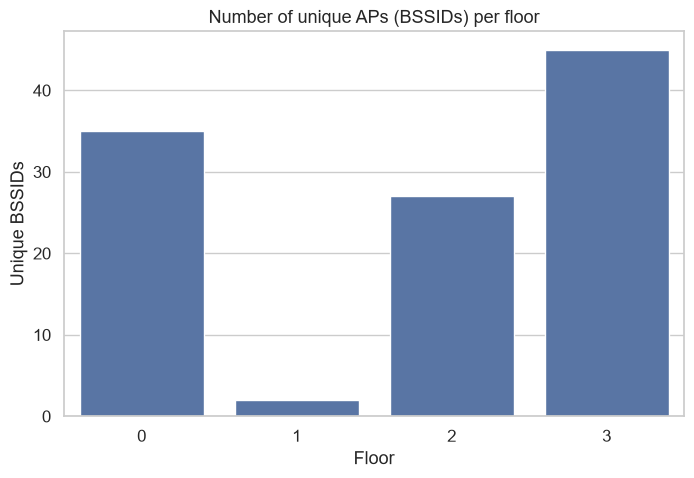

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(data=per_floor, x="Floor", y="Unique_BSSIDs", color="#4C72B0")
plt.title("Number of unique APs (BSSIDs) per floor")
plt.xlabel("Floor"); plt.ylabel("Unique BSSIDs")
plt.show()

## ۷. تعداد AP قابل مشاهده در هر Reference Point

هرچه در یک نقطه APهای بیشتری قابل مشاهده باشند، اثر انگشت (fingerprint) غنی‌تر و مکان‌یابی دقیق‌تر است.

In [9]:
per_rp = (df.groupby("ReferencePointID")
            .agg(Unique_BSSIDs=("WifiBSSID","nunique"),
                 Observations=("WifiRSSI","count"),
                 Mean_RSSI_dBm=("WifiRSSI","mean"))
            .reset_index().sort_values("Unique_BSSIDs", ascending=False))
per_rp["Mean_RSSI_dBm"] = per_rp["Mean_RSSI_dBm"].round(2)
per_rp.head(15)

,ReferencePointID,Unique_BSSIDs,Observations,Mean_RSSI_dBm
27,AB 425_F3,25,61,-72.11
29,AB 427_F3,24,57,-75.53
24,AB 422_F3,23,46,-73.76
11,AB 409_F3,22,55,-69.71
28,AB 426_F3,22,46,-73.80
26,AB 424_F3,22,41,-71.85
7,AB 405_F3,22,45,-71.29
33,BC 105_F0,22,57,-74.18
30,AB 428_F3,22,46,-72.93
21,AB 419_F3,21,38,-73.32


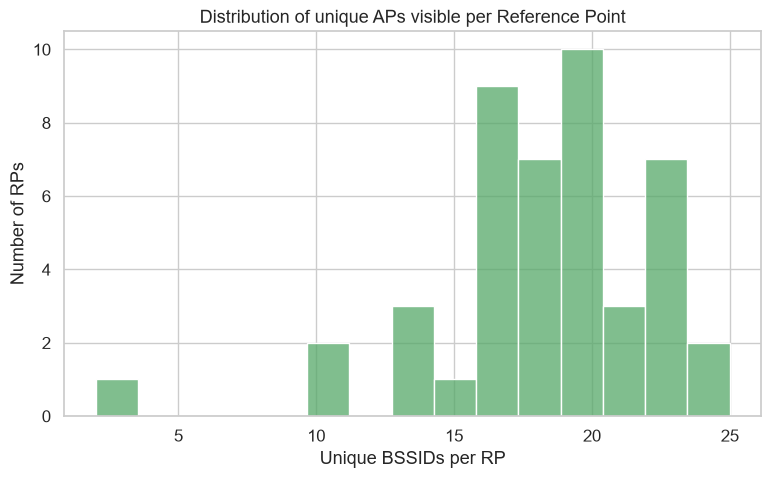

In [10]:
plt.figure(figsize=(9,5))
sns.histplot(per_rp["Unique_BSSIDs"], bins=15, color="#55A868")
plt.title("Distribution of unique APs visible per Reference Point")
plt.xlabel("Unique BSSIDs per RP"); plt.ylabel("Number of RPs")
plt.show()

## ۸. توزیع و هیستوگرام RSSI

توزیع RSSI به ما می‌گوید سیگنال‌ها چقدر قوی/ضعیف هستند. مقادیر نزدیک به 0 قوی‌ترند.

In [11]:
print(df["WifiRSSI"].describe().round(2))

count    1756.00
mean      -72.21
std        15.52
min       -96.00
25%       -85.00
50%       -77.00
75%       -62.00
max       -31.00
Name: WifiRSSI, dtype: float64


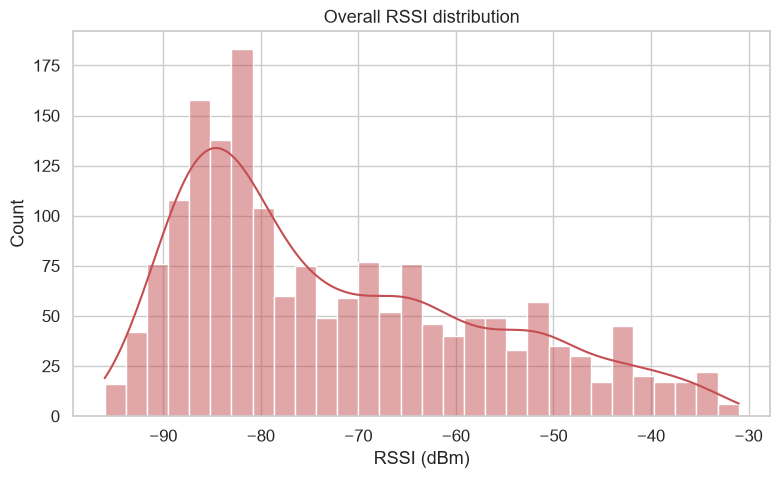

In [12]:
plt.figure(figsize=(9,5))
sns.histplot(df["WifiRSSI"], bins=30, kde=True, color="#C44E52")
plt.title("Overall RSSI distribution")
plt.xlabel("RSSI (dBm)"); plt.ylabel("Count")
plt.show()

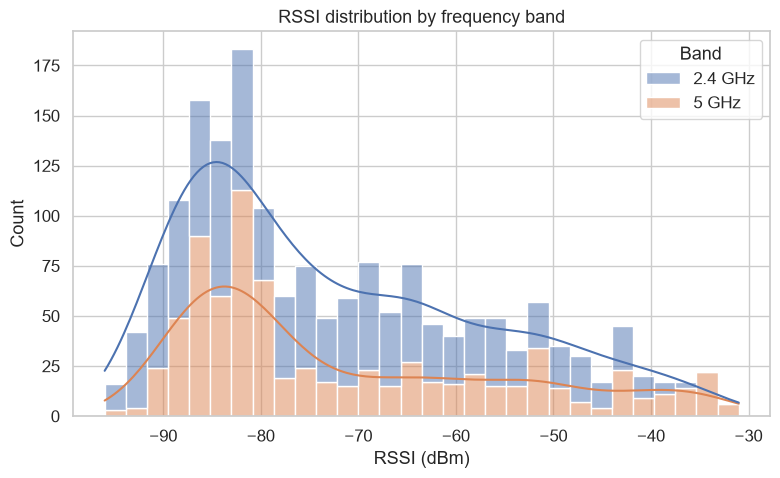

In [13]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="WifiRSSI", hue="Band", bins=30, kde=True, multiple="stack")
plt.title("RSSI distribution by frequency band")
plt.xlabel("RSSI (dBm)"); plt.ylabel("Count")
plt.show()

## ۹. باکس‌پلات پایداری ۱۲ AP برتر

هرچه **جعبه کوچک‌تر** و **میانگین بالاتر (نزدیک‌تر به صفر)** باشد، آن AP پایدارتر و برای مکان‌یابی مناسب‌تر است.

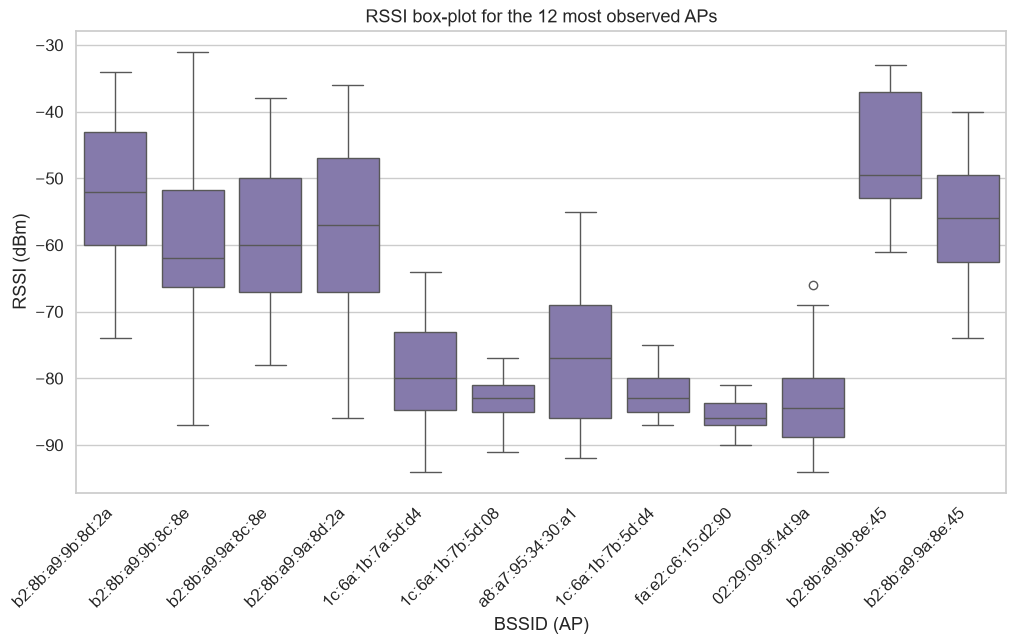

In [14]:
top = agg.head(12)["WifiBSSID"].tolist()
sub = df[df["WifiBSSID"].isin(top)]
plt.figure(figsize=(12,6))
sns.boxplot(data=sub, x="WifiBSSID", y="WifiRSSI", order=top, color="#8172B3")
plt.title("RSSI box-plot for the 12 most observed APs")
plt.xlabel("BSSID (AP)"); plt.ylabel("RSSI (dBm)")
plt.xticks(rotation=45, ha="right")
plt.show()

## ۱۰. پوشش APها

در چند درصد نقاط مرجع هر AP دیده شده است؟ APهایی با پوشش بالا، «لنگر»های خوبی برای fingerprinting هستند.

In [15]:
COVERAGE_THRESHOLD = 0.80
cov = df.groupby("WifiBSSID")["ReferencePointID"].nunique().sort_values(ascending=False)
coverage_pct = (cov / total_rp * 100).round(1)
widespread = coverage_pct[coverage_pct >= COVERAGE_THRESHOLD*100]
print(f"APهایی که در بیش از ۸۰٪ RPها دیده شده‌اند: {len(widespread)} از {len(coverage_pct)} AP")
cov_df = coverage_pct.reset_index()
cov_df.columns = ["WifiBSSID","Coverage_pct"]
cov_df["Widespread(>=80%)"] = np.where(cov_df["Coverage_pct"] >= COVERAGE_THRESHOLD*100, "YES", "NO")
cov_df.head(15)

APهایی که در بیش از ۸۰٪ RPها دیده شده‌اند: 0 از 76 AP


,WifiBSSID,Coverage_pct,Widespread(>=80%)
0,1c:6a:1b:7a:5d:d4,66.7,NO
1,b2:8b:a9:9a:8c:8e,66.7,NO
2,b2:8b:a9:9b:8d:2a,66.7,NO
3,b2:8b:a9:9a:8d:2a,66.7,NO
4,b2:8b:a9:9b:8c:8e,66.7,NO
5,1c:6a:1b:7b:5d:08,62.2,NO
6,1c:6a:1b:7b:5d:d4,55.6,NO
7,a8:a7:95:34:30:a1,55.6,NO
8,fa:e2:c6:15:d2:90,53.3,NO
9,ac:8b:a9:9b:8c:8e,44.4,NO


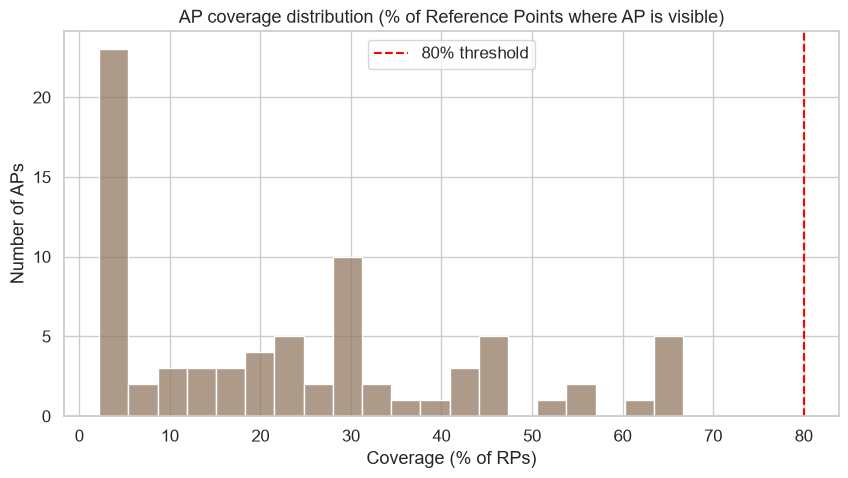

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(coverage_pct, bins=20, color="#937860")
plt.axvline(COVERAGE_THRESHOLD*100, color="red", linestyle="--", label="80% threshold")
plt.title("AP coverage distribution (% of Reference Points where AP is visible)")
plt.xlabel("Coverage (% of RPs)"); plt.ylabel("Number of APs")
plt.legend(); plt.show()

## ۱۱. همبستگی RSSI با فاصله از Reference Point

اگر مدل ایده‌آل باشد، با دور شدن از مرکز یک نقطه مرجع، RSSI باید کاهش یابد (همبستگی منفی).

In [17]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2-lat1); dl = np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

rp_center = df.groupby("ReferencePointID")[["GPS_Latitude","GPS_Longitude"]].mean()
rows = []
for rp, grp in df.groupby("ReferencePointID"):
    if rp not in rp_center.index: continue
    clat, clon = rp_center.loc[rp]
    d = haversine_m(grp["GPS_Latitude"].values, grp["GPS_Longitude"].values, clat, clon)
    tmp = grp[["WifiRSSI"]].copy(); tmp["Distance_m"] = d
    rows.append(tmp)
dist_df = pd.concat(rows)
corr = dist_df["WifiRSSI"].corr(dist_df["Distance_m"])
print(f"همبستگی پیرسون بین RSSI و فاصله تا مرکز RP: {corr:.3f}")

همبستگی پیرسون بین RSSI و فاصله تا مرکز RP: -0.009


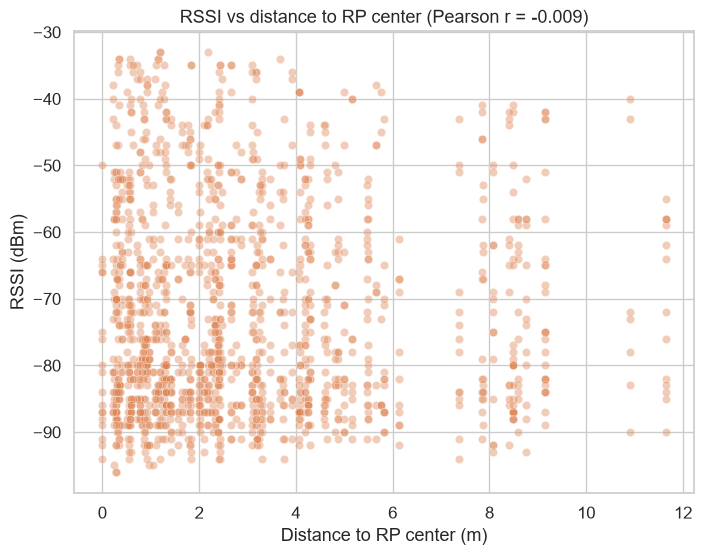

In [18]:
plt.figure(figsize=(8,6))
sample = dist_df.sample(min(len(dist_df),1500), random_state=42)
sns.scatterplot(data=sample, x="Distance_m", y="WifiRSSI", alpha=0.4, color="#DD8452")
plt.title(f"RSSI vs distance to RP center (Pearson r = {corr:.3f})")
plt.xlabel("Distance to RP center (m)"); plt.ylabel("RSSI (dBm)")
plt.show()

## ۱۲. ماتریس ساختمان × طبقه

این ماتریس نشان می‌دهد توزیع APها در ساختمان‌ها و طبقات چگونه است.

In [19]:
pivot = df.pivot_table(index="Building", columns="Floor",
                        values="WifiBSSID", aggfunc="nunique", fill_value=0)
pivot

Floor,0,1,2,3
Building,,,,
1,0,2,0,0
AB,0,0,27,35
B,30,0,0,0
BC,24,0,0,0
C,0,0,0,38


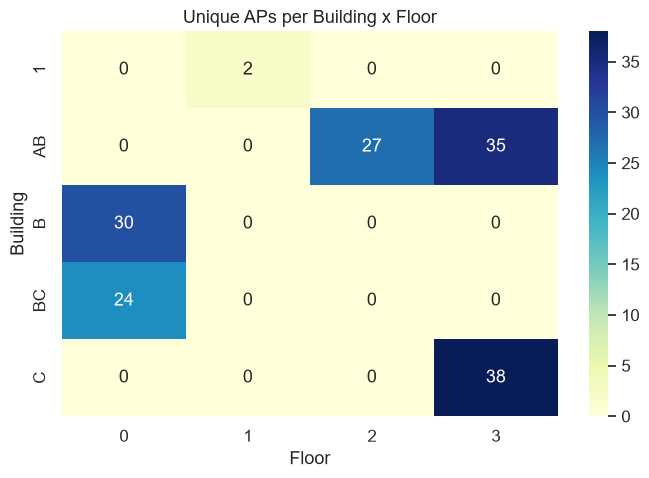

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Unique APs per Building x Floor")
plt.xlabel("Floor"); plt.ylabel("Building")
plt.show()

## ۱۳. مجموعه پیشنهادی APها برای Fingerprinting

این جدول نتیجه نهایی است: APهایی که حداقل ۱۰ بار دیده شده‌اند، همراه با یادداشت پایداری (Std ≤ 6 = پایدار).

In [21]:
rec = agg[agg["Observations"] >= MIN_OBSERVATIONS].copy()
rec["Stability_note"] = np.where(rec["Std_RSSI"] <= 6, "stable", "noisy")
rec = rec.sort_values(["Coverage_pct","Observations"], ascending=[False,False])
print(f"تعداد AP پیشنهادی: {len(rec)} از {len(agg)} AP")
rec[["WifiBSSID","SSID","Observations","Mean_RSSI_dBm","Std_RSSI","Band","Coverage_pct","Stability_note"]]

تعداد AP پیشنهادی: 48 از 76 AP


,WifiBSSID,SSID,Observations,Mean_RSSI_dBm,Std_RSSI,Band,Coverage_pct,Stability_note
0,b2:8b:a9:9b:8d:2a,WiFi-FUM,84,-51.86,10.57,5 GHz,66.7,noisy
1,b2:8b:a9:9b:8c:8e,WiFi-FUM,84,-59.29,11.09,5 GHz,66.7,noisy
2,b2:8b:a9:9a:8c:8e,WiFi-FUM,82,-58.66,10.37,2.4 GHz,66.7,noisy
3,b2:8b:a9:9a:8d:2a,WiFi-FUM,81,-56.79,12.46,2.4 GHz,66.7,noisy
4,1c:6a:1b:7a:5d:d4,WiFi-FUM,78,-78.83,7.53,2.4 GHz,66.7,noisy
5,1c:6a:1b:7b:5d:08,WiFi-FUM,68,-82.96,2.98,5 GHz,62.2,stable
6,a8:a7:95:34:30:a1,HP-Print-A1-LaserJet Pro MFP,59,-76.63,10.45,2.4 GHz,55.6,noisy
7,1c:6a:1b:7b:5d:d4,WiFi-FUM,53,-82.53,3.29,5 GHz,55.6,stable
8,fa:e2:c6:15:d2:90,WiFi-FUM,52,-85.54,2.35,5 GHz,53.3,stable
18,ac:8b:a9:9b:8c:8e,None,35,-58.34,12.15,5 GHz,44.4,noisy


## جمع‌بندی

| معیار | مقدار |
|------|------|
| مجموع APهای شناسایی‌شده | ۷۶ |
| APهای مناسب (≥ ۱۰ مشاهده) | ۴۸ |
| شبکه غالب | WiFi-FUM (۲۶ BSSID) |
| باند غالب | 2.4 GHz (۹۷۷ ردیف) و 5 GHz (۷۷۹ ردیف) |
| محدوده RSSI | ۹۶- تا ۳۱- dBm |

**نتیجه برای ارائه:** از ۷۶ اکسس‌پوینت موجود در محیط، تنها حدود **۴۸ عدد** برای مکان‌یابی مبتنی بر Fingerprinting مناسب هستند (آنهایی که به‌طور پایدار و مکرر در نقاط مرجع مشاهده شده‌اند). بقیه یا تنها یک‌بار دیده شده‌اند (مثل هات‌اسپات گوشی‌های عبوری) یا پایداری بسیار پایینی دارند و باید فیلتر شوند.